<h1>Credit card Fraud detection predictive model</h1>

This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation.

Due to confidentiality issues, there are not provided the original features and more background information about the data.

<h1>Importing the dataset and libraries and defining values for future use</h1>

In [1]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)


import gc
from datetime import datetime 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn import svm
import lightgbm as lgb
from lightgbm import LGBMClassifier
import xgboost as xgb

pd.set_option('display.max_columns', 100)


RFC_METRIC = 'gini' 
NUM_ESTIMATORS = 100 
NO_JOBS = 4 



VALID_SIZE = 0.20 
TEST_SIZE = 0.20 
NUMBER_KFOLDS = 5 



RANDOM_STATE = 2018

MAX_ROUNDS = 1000 
EARLY_STOP = 50 
OPT_ROUNDS = 1000 
VERBOSE_EVAL = 50 

<h2>Importing the data<h1>

In [2]:
data_df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

<h2>Checking the data</h2>

In [3]:
print("Credit card fraud detection data - rows:", data_df.shape[0],"Columns:",data_df.shape[1])

Credit card fraud detection data - rows: 284807 Columns: 31


In [4]:
#Checking some of the rows in data

data_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
#More details of the credit cards

data_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
#Checking for missing values in data

total=data_df.isnull().sum().sort_values(ascending = False)
percent =(data_df.isnull().sum()/data_df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total,percent], axis =1, keys=['Total','Percent']).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


There is no missing value in the dataset

<h2>Checking Unbalanced data</h2>

In [7]:
temp=data_df["Class"].value_counts()
df=pd.DataFrame({'Class': temp.index, 'values':temp.values})

trace= go.Bar(
    x=df["Class"],y=df["values"],
    name="Credit card fraud - data unbalanced(Not fraud=0, fraud =1)",
    marker=dict(color ="Red"),
    text=df["values"]
)

data=[trace]
layout=dict(title='Credit Card Fraud Class - data unbalance (Not fraud = 0, Fraud = 1)',
           xaxis=dict(title='Class', showticklabels=True),
            yaxis=dict(title='Number of transactions'),
            hovermode='closest',width=600
           )

fig = dict(data=data, layout=layout)
iplot(fig, filename='class')

Only 492 (or 0.172%) of transaction are fraudulent. That means the data is highly unbalanced with respect with target variable Class.

<h1>Data Exploration</h1>

<h2>Transactions in times</h2>

In [8]:
class_0 = data_df.loc[data_df['Class'] == 0]["Time"]
class_1 = data_df.loc[data_df['Class'] == 1]["Time"]

hist_data = [class_0, class_1]
group_labels = ['Not Fraud', 'Fraud']

fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)
fig['layout'].update(title='Credit Card Transactions Time Density Plot', xaxis=dict(title='Time [s]'))
iplot(fig, filename='dist_only')

Fraudulent transactions have a distribution more even than valid transactions - are equaly distributed in time, including the low real transaction times, during night in Europe timezone.

Let's look into more details to the time distribution of both classes transaction, as well as to aggregated values of transaction count and amount, per hour. We assume (based on observation of the time distribution of transactions) that the time unit is second.

<H2>Grouping data to make it easy for visualization</H2>

In [9]:
data_df['Hour'] = data_df['Time'].apply(lambda x: np.floor(x / 3600))

tmp = data_df.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
df = pd.DataFrame(tmp)
df.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']
df.head()

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


<h2>Hours vs Sum of money spent </h2>

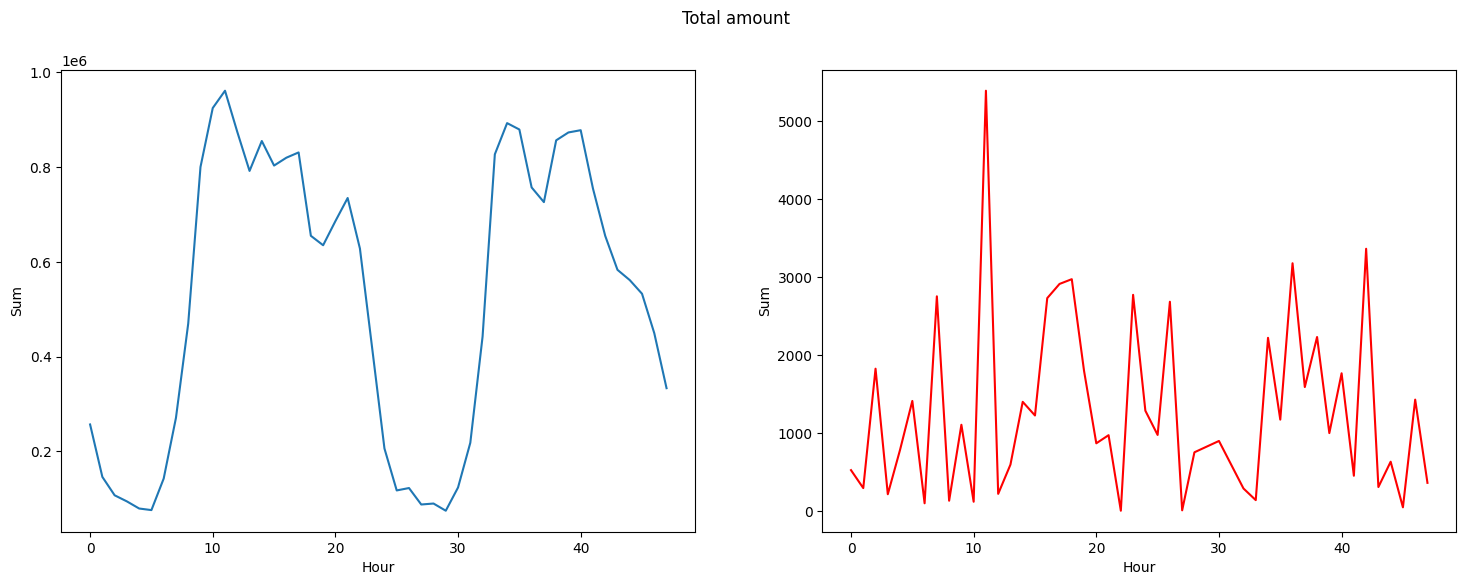

In [10]:
fig, (ax1,ax2) =plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax=ax1, x="Hour", y="Sum", data=df.loc[df.Class==0])
s= sns.lineplot(ax=ax2, x="Hour",y="Sum",data=df.loc[df.Class==1],color ="red")
plt.suptitle("Total amount")
plt.show()

We can see that during the 9-11th hour the sum of spending increased a lot showing a decling slowly afterwards

<h2>Plotting graph for transaction per hour</h2>

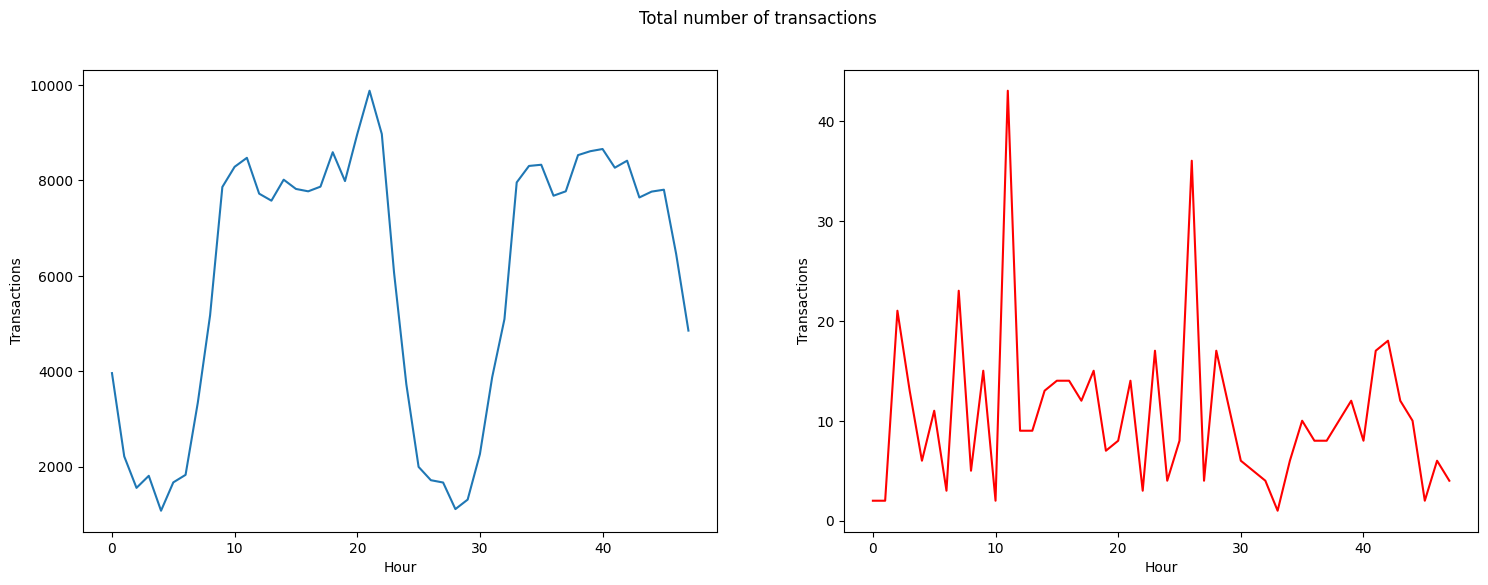

In [11]:
fig, (ax1,ax2) =plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax=ax1, x="Hour", y="Transactions", data=df.loc[df.Class==0])
s= sns.lineplot(ax=ax2, x="Hour",y="Transactions",data=df.loc[df.Class==1],color ="red")
plt.suptitle("Total number of transactions")
plt.show();

We can see that the number of transactions increased exponentially after ~6th hour of theft spiking upto 9000+ between 19-21st hour and then declining afterwards we can see a sharp rise again after 29th hour of the theft

<h2>Plotting graph for avg transaction per hour</h2>

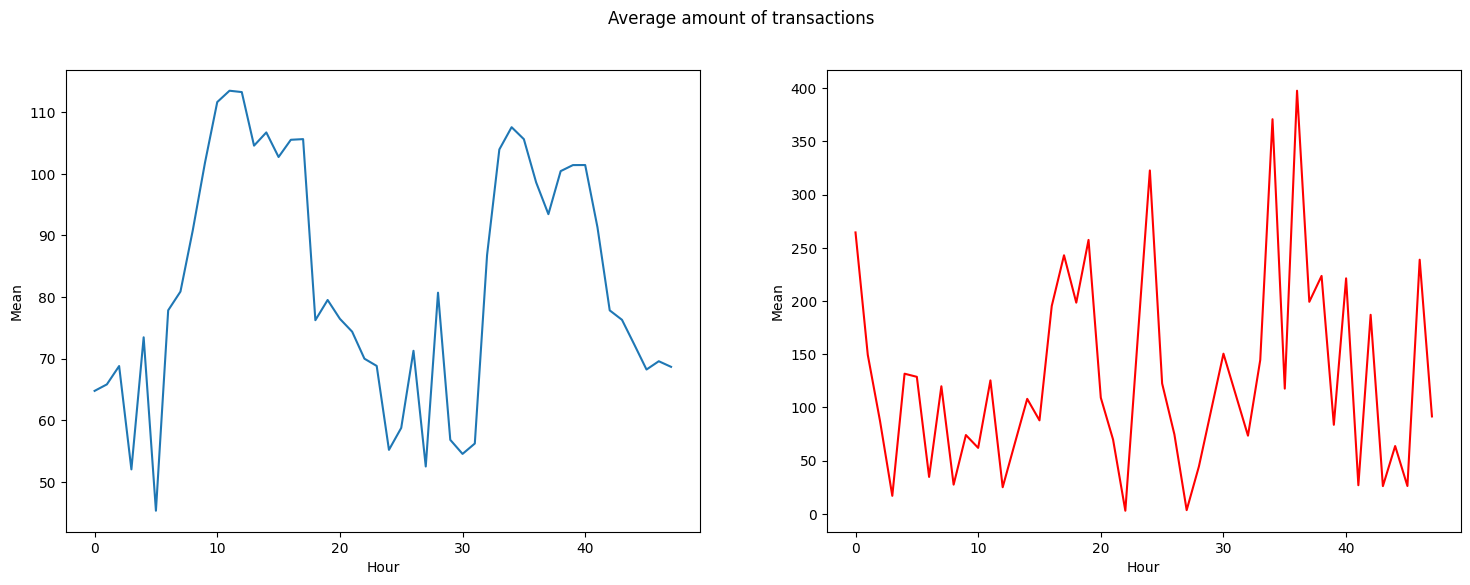

In [12]:
fig, (ax1,ax2) =plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax=ax1, x="Hour", y="Mean", data=df.loc[df.Class==0])
s= sns.lineplot(ax=ax2, x="Hour",y="Mean",data=df.loc[df.Class==1],color ="red")
plt.suptitle("Average amount of transactions")
plt.show()

We can see that the avg transactions peaks at 110+ transaction and then declining slowly

<h2>Max transaction per hour visualization</h2>

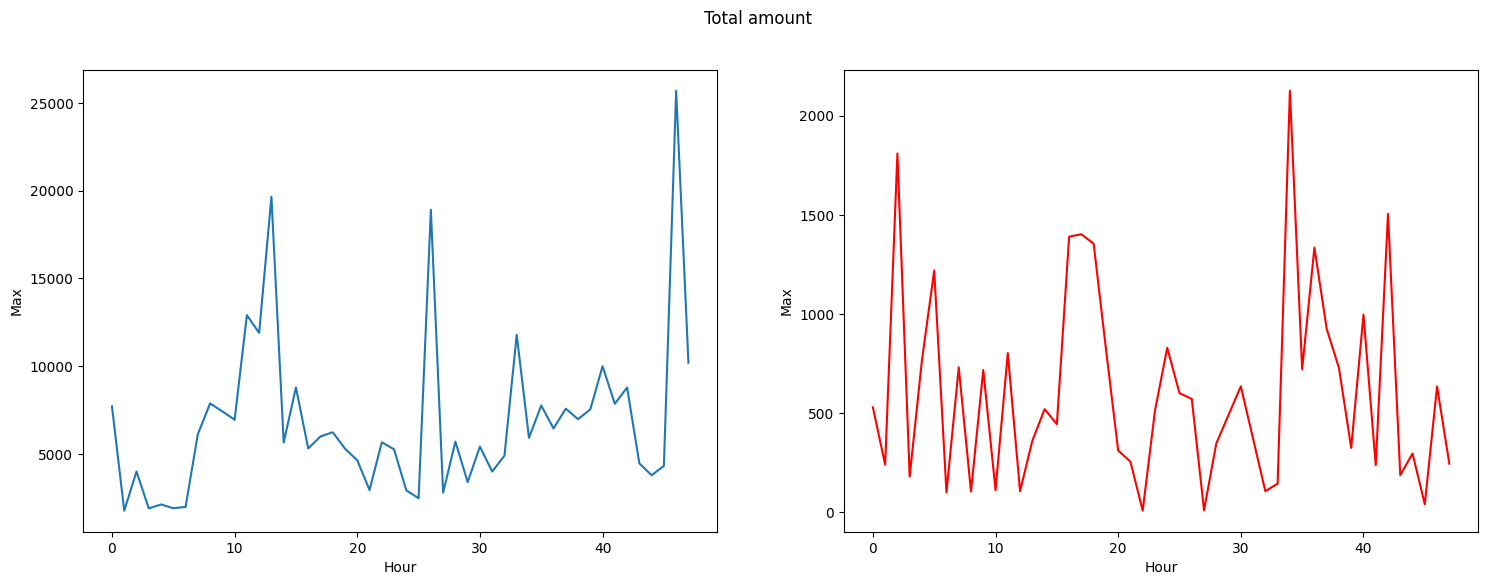

In [13]:
fig, (ax1,ax2) =plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax=ax1, x="Hour", y="Max", data=df.loc[df.Class==0])
s= sns.lineplot(ax=ax2, x="Hour",y="Max",data=df.loc[df.Class==1],color ="red")
plt.suptitle("Total amount")
plt.show()

We can see that the max credit card transaction reached upto 25k+ at around 45th hour of theft and then declining steeply

<h2>Median transaction per hour visualization </h2>

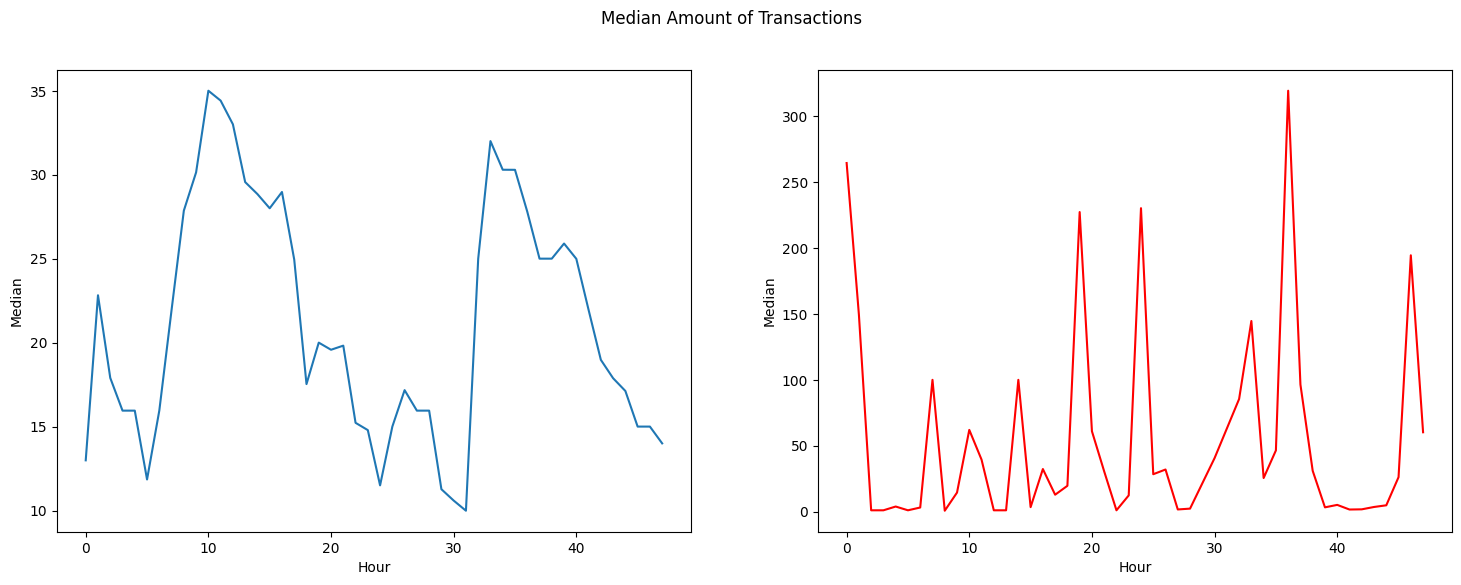

In [14]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Median", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Median", data=df.loc[df.Class==1], color="red")
plt.suptitle("Median Amount of Transactions")
plt.show();

<h2>Transaction amount</h2>

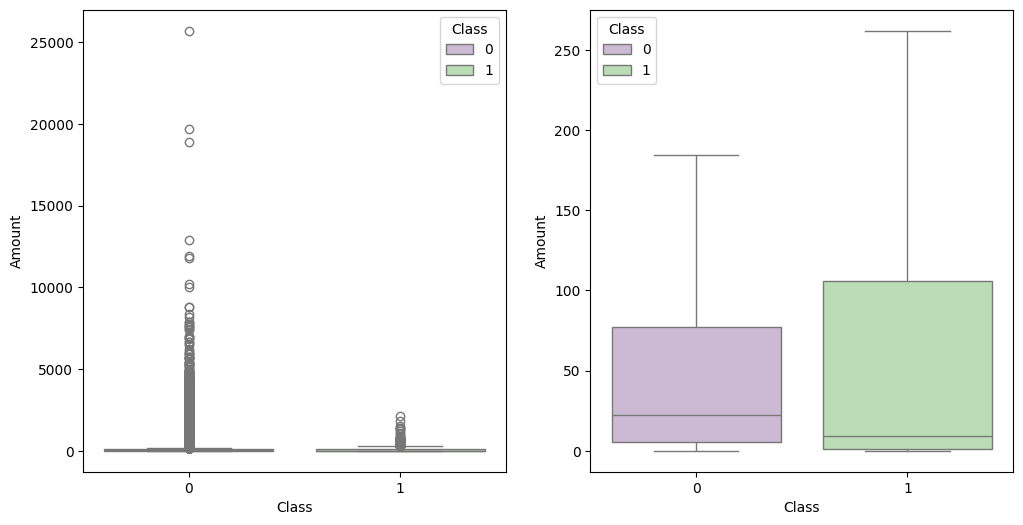

In [15]:
fig,(ax1,ax2)=plt.subplots(ncols=2, figsize=(12,6))

s=sns.boxplot(ax=ax1, x="Class", y="Amount",hue="Class", data=data_df,palette="PRGn",showfliers=True)
s=sns.boxplot(ax=ax2, x="Class",y="Amount",hue ="Class", data=data_df,palette="PRGn",showfliers=False)
plt.show()

We can seee that sometimes we have a very high amount spending ~15k+ but generally the transaction amount is between ~7.5k$ and 0$

In [16]:
#Analysing the max, min and avg spending on credit card
tmp=data_df[['Amount','Class']].copy()
class_0=tmp.loc[tmp['Class']==0]['Amount']
class_1=tmp.loc[tmp['Class']==1]['Amount']
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [17]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

The real transaction have a larger mean value, larger Q1, smaller Q3 and Q4 and larger outliers; fraudulent transactions have a smaller Q1 and mean, larger Q4 and smaller outliers.

<h2>Plotting graph for Fraud transactions per second </h2>

In [18]:
fraud = data_df.loc[data_df['Class'] == 1]

trace = go.Scatter(
    x = fraud['Time'],y = fraud['Amount'],
    name="Amount",
     marker=dict(
                color='rgb(238,23,11)',
                line=dict(
                    color='red',
                    width=1),
                opacity=0.5,
            ),
    text= fraud['Amount'],
    mode = "markers"
)

data= [trace]

layout=dict(title="Amount of fraudlent transactions",
           xaxis=dict(title='Time', showticklabels=True),
            yaxis=dict(title="Amount"),
            hovermode='closest'
           )

fig = dict(data=data, layout=layout)
iplot(fig,filename='fraud-amount')

<h2>Feature correlation</h2>

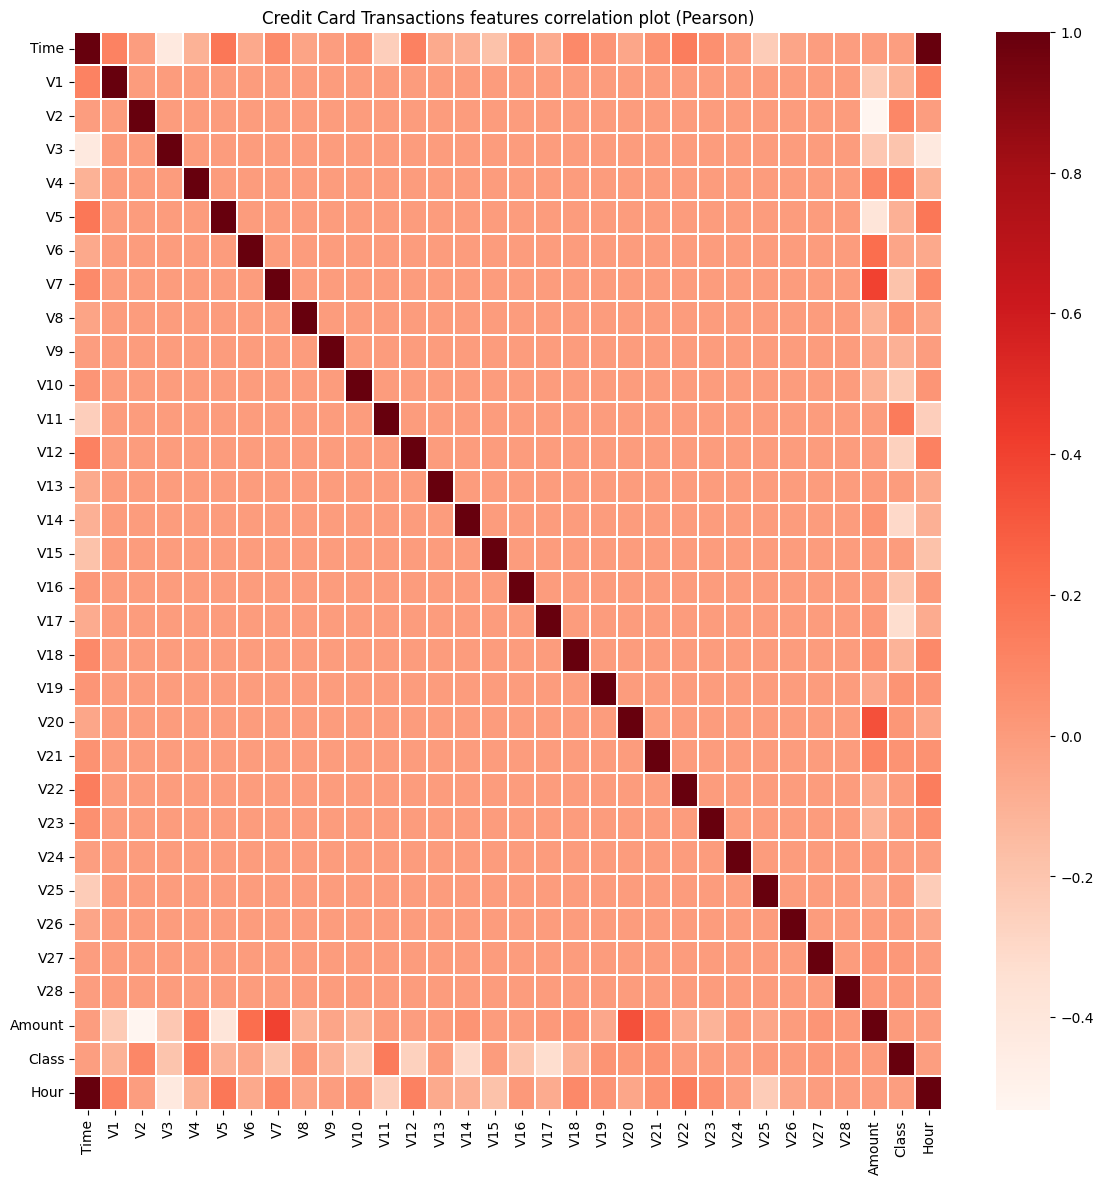

In [19]:
plt.figure(figsize = (14,14))
plt.title('Credit Card Transactions features correlation plot (Pearson)')
corr = data_df.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,cmap="Reds")
plt.show()

The above image shows the relationship between different features.
As expected, there is no notable correlation between features V1-V28. There are certain correlations between some of these features and Time (inverse correlation with V3) and Amount (direct correlation with V7 and V20, inverse correlation with V1 and V5).

<h2>Plotting correlated and inverse correlated values on same graph</h2>

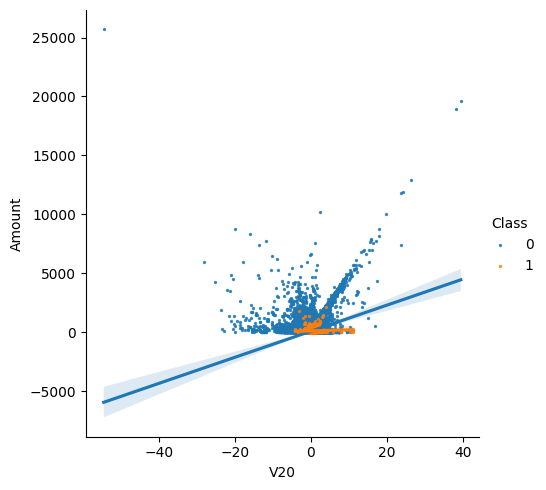

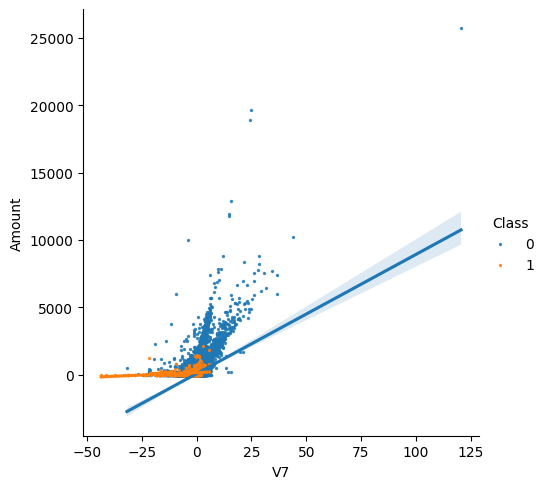

In [20]:
s = sns.lmplot(x='V20', y='Amount', data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
s = sns.lmplot(x='V7', y='Amount', data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
plt.show()

Two couples of features are correlated (the regression lines for Class = 0 have a positive slope, whilst the regression line for Class = 1 have a smaller positive slope).

<h2>Inverse correlated values</h2>

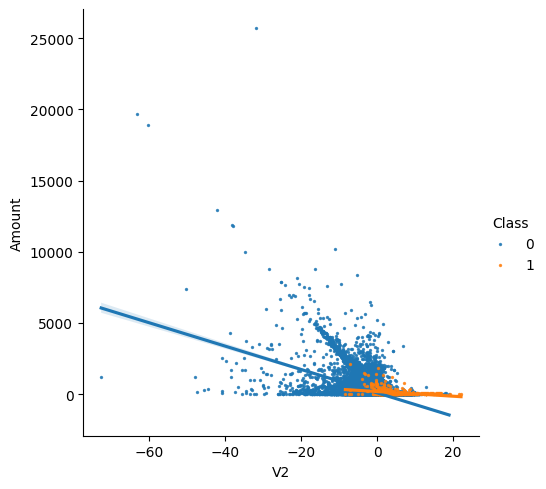

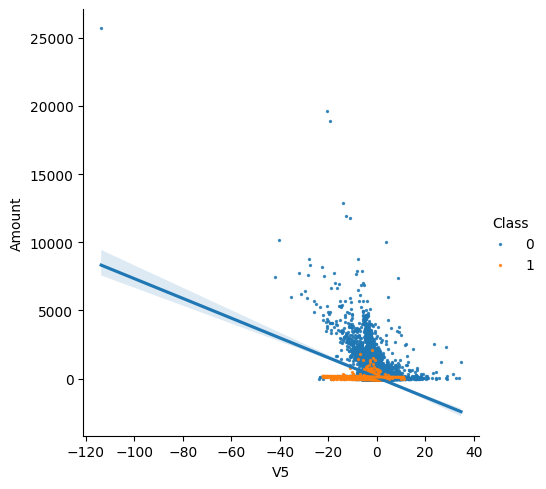

In [21]:
s = sns.lmplot(x='V2', y='Amount',data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
s = sns.lmplot(x='V5', y='Amount',data=data_df, hue='Class', fit_reg=True,scatter_kws={'s':2})
plt.show()

We can confirm that the two couples of features are inverse correlated (the regression lines for Class = 0 have a negative slope while the regression lines for Class = 1 have a very small negative slope).

<h2>Feature density plot</h2>

/tmp/ipykernel_55/1262157093.py:14: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


/tmp/ipykernel_55/1262157093.py:15: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


/tmp/ipykernel_55/1262157093.py:14: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


/tmp/ipykernel_55/1262157093.py:15: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameter

<Figure size 640x480 with 0 Axes>

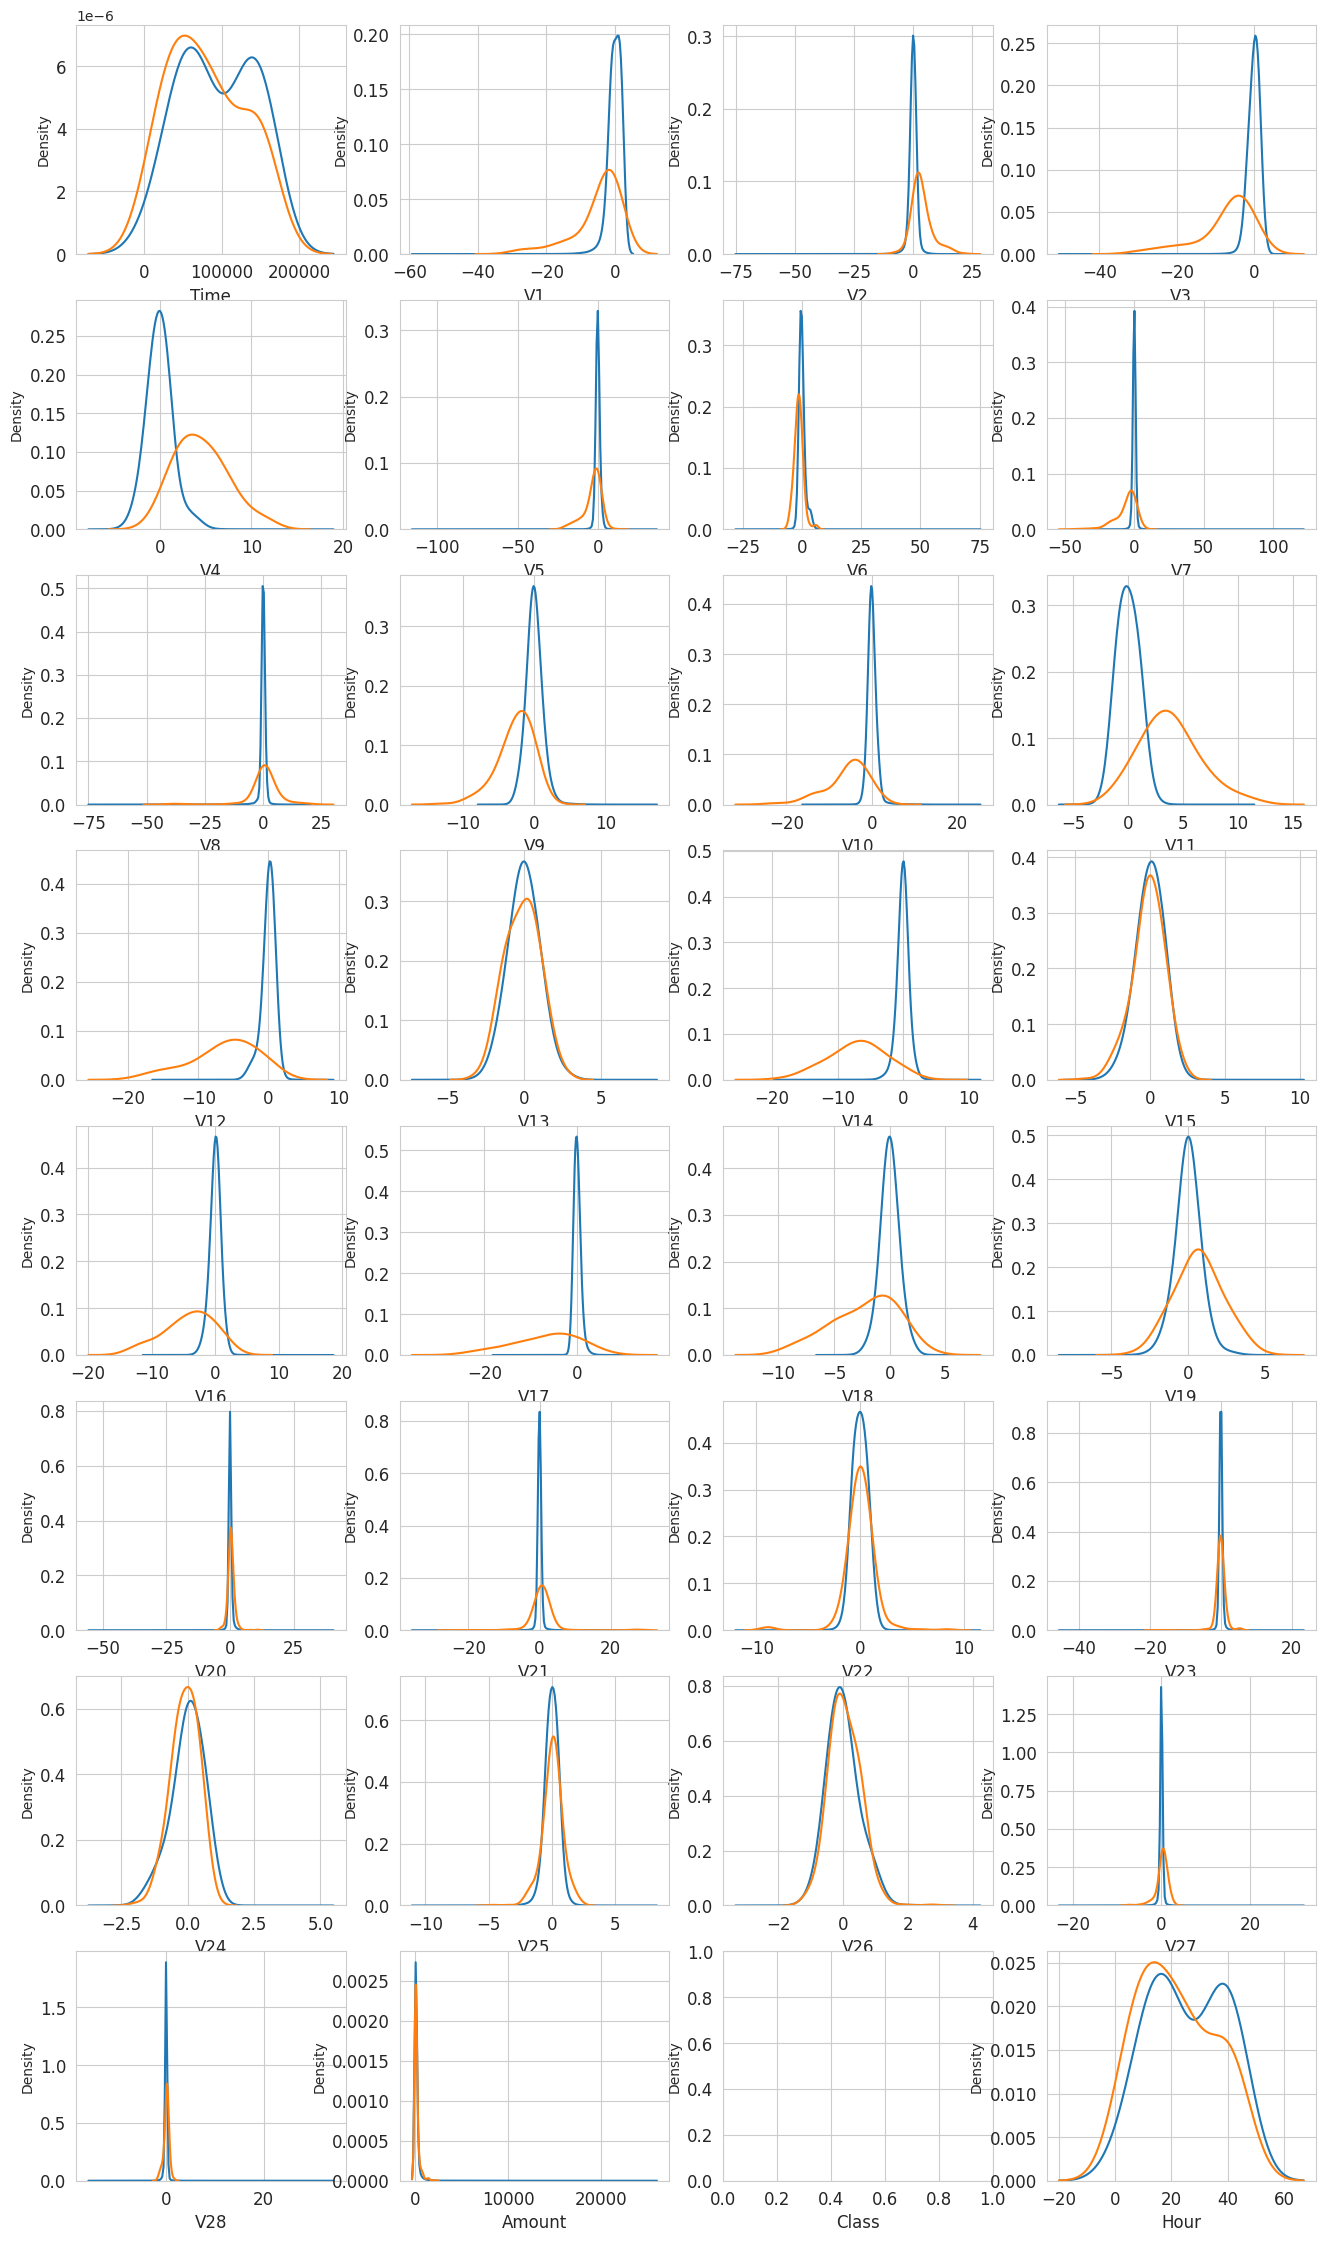

In [22]:
var = data_df.columns.values

i = 0
t0 = data_df.loc[data_df['Class'] == 0]
t1 = data_df.loc[data_df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw=0.5,label="Class = 0")
    sns.kdeplot(t1[feature], bw=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show();




For some of the features we can observe a good selectivity in terms of distribution for the two values of Class: V4, V11 have clearly separated distributions for Class values 0 and 1, V12, V14, V18 are partially separated, V1, V2, V3, V10 have a quite distinct profile, whilst V25, V26, V28 have similar profiles for the two values of Class.

In general, with just few exceptions (Time and Amount), the features distribution for legitimate transactions (values of Class = 0) is centered around 0, sometime with a long queue at one of the extremities. In the same time, the fraudulent transactions (values of Class = 1) have a skewed (asymmetric) distribution.


<h1>Predictive models</h1>

<h3>Define predictors and values</h3>

Let's define the predictor features and the target features. Categorical features, if any, are also defined. In our case, there are no categorical feature.

In [23]:
target = 'Class'
predictors = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',\
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',\
       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',\
       'Amount']

<h3>Split data in train, test and validation set</h3>

In [24]:
train_df, test_df = train_test_split(data_df, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True )
train_df, valid_df = train_test_split(train_df, test_size=VALID_SIZE, random_state=RANDOM_STATE, shuffle=True )

<h2>RandomForest classifier </h2>

We will use as validation criterion GINI, which formula is GINI = 2 * (AUC) - 1, where AUC is the Receiver Operating Characteristic - Area Under Curve (ROC-AUC). Number of estimators is set to 100 and number of parallel jobs is set to 4.

We start by initializing the RandomForestClassifier.

In [25]:
clf = RandomForestClassifier(n_jobs=NO_JOBS, 
                             random_state=RANDOM_STATE,
                             criterion=RFC_METRIC,
                             n_estimators=NUM_ESTIMATORS,
                             verbose=False)

<h3>Let's train the RandonForestClassifier using the train_df data and fit function</h3>

In [26]:
clf.fit(train_df[predictors], train_df[target].values)

RandomForestClassifier(n_jobs=4, random_state=2018, verbose=False)

<h3>Let's now predict the target values for the valid_df data, using predict function</h3>

In [27]:
preds= clf.predict(valid_df[predictors])

<h3>Visualizing feature importance</h3>

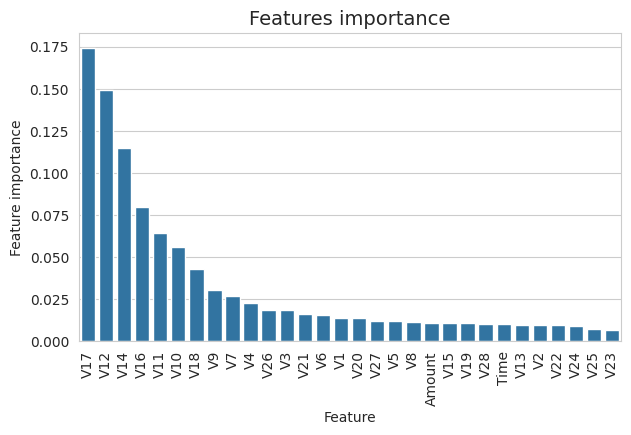

In [28]:
tmp = pd.DataFrame({'Feature': predictors, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)

s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.tick_params(axis='x', rotation=90)
plt.show()

The most important features are V17, V12, V14, V10, V11, V16.

<h3>Confusion matrix</h3>

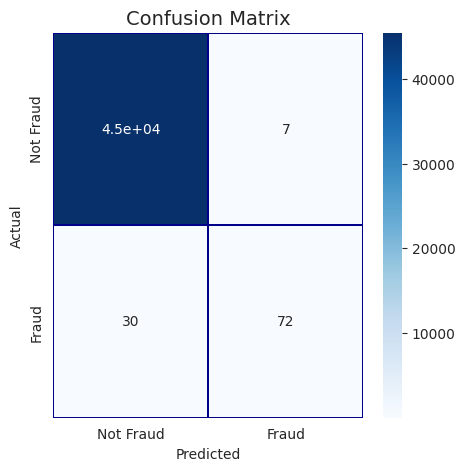

In [29]:
cm = pd.crosstab(valid_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm, 
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()

We need to clarify that confussion matrix are not a very good tool to represent the results in the case of largely unbalanced data, because we will actually need a different metrics that accounts in the same time for the selectivity and specificity of the method we are using, so that we minimize in the same time both Type I errors and Type II errors.

Null Hypothesis (H0) - The transaction is not a fraud.
Alternative Hypothesis (H1) - The transaction is a fraud.

Type I error - You reject the null hypothesis when the null hypothesis is actually true.
Type II error - You fail to reject the null hypothesis when the the alternative hypothesis is true.

Cost of Type I error - You erroneously presume that the the transaction is a fraud, and a true transaction is rejected.
Cost of Type II error - You erroneously presume that the transaction is not a fraud and a ffraudulent transaction is accepted.

<h3>Lets calculate ROC-AUC score</h3>

<h3>Area under curve</h3>

In [30]:
roc_auc_score(valid_df[target].values,preds)

np.float64(0.8528641975628091)

The ROC-AUD values obtained with randomforext classifier is 0.85

<h2>AdaBoostClassifier</h2>

<h3>Preparing the model</h3>

In [31]:
clf = AdaBoostClassifier(random_state=RANDOM_STATE,
                         learning_rate=0.8,
                             n_estimators=NUM_ESTIMATORS)

<h3>Fit the model</h3>

In [32]:
clf.fit(train_df[predictors], train_df[target].values)

AdaBoostClassifier(learning_rate=0.8, n_estimators=100, random_state=2018)

<h3>Predict target values</h3>

In [33]:
preds = clf.predict(valid_df[predictors])

<h3>Feature importance</h3>

/tmp/ipykernel_55/3992975389.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



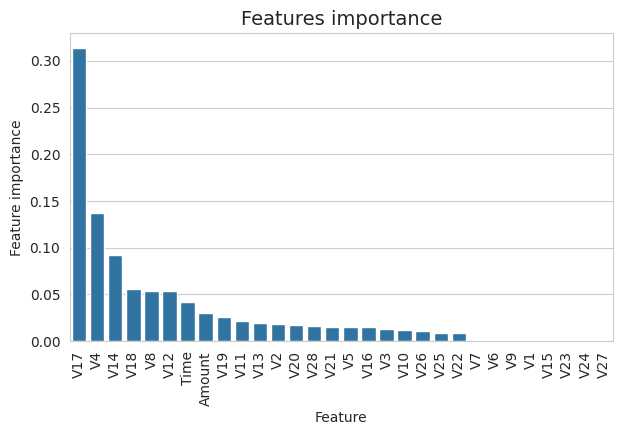

In [34]:
tmp = pd.DataFrame({'Feature': predictors, 'Feature importance': clf.feature_importances_})
tmp = tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (7,4))
plt.title('Features importance',fontsize=14)
s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()   

We can see that the feature V17 has the highest importance

<h3>Confusion matrix</h3>

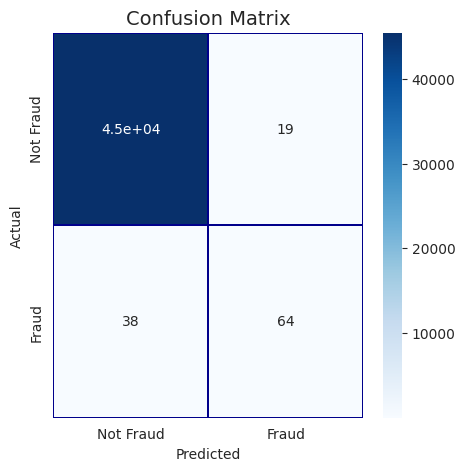

In [35]:
cm = pd.crosstab(valid_df[target].values, preds, rownames=['Actual'], colnames=['Predicted'])
fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
sns.heatmap(cm, 
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
plt.title('Confusion Matrix', fontsize=14)
plt.show()


<h3>Calculate the ROC-AUC</h3>

<h3>Area under curve</h3>

In [36]:
roc_auc_score(valid_df[target].values,preds)

np.float64(0.8135165474463918)

The ROC-AUC values of AdaBoostClassifier is 0.8135165474463918

<h2>CatBoostClassifier</h2>

In [37]:
clf=CatBoostClassifier(iterations=500,
                      learning_rate=0.02,
                      depth=12,
                      eval_metric='AUC',
                      random_seed=RANDOM_STATE,
                      bagging_temperature=0.2,
                      od_type='Iter',
                      metric_period=VERBOSE_EVAL,
                      od_wait=100)

In [38]:
clf.fit(train_df[predictors],train_df[target].values, verbose=True)

0:	total: 436ms	remaining: 3m 37s
50:	total: 16.9s	remaining: 2m 28s
100:	total: 33.1s	remaining: 2m 10s
150:	total: 48.7s	remaining: 1m 52s
200:	total: 1m 3s	remaining: 1m 34s
250:	total: 1m 20s	remaining: 1m 19s
300:	total: 1m 35s	remaining: 1m 2s
350:	total: 1m 46s	remaining: 45.2s
400:	total: 1m 57s	remaining: 29.1s
450:	total: 2m 8s	remaining: 14s
499:	total: 2m 19s	remaining: 0us


<h3>Predict the target values</h3>

In [39]:
preds=clf.predict(valid_df[predictors])

<h3>Feature importance</h3>

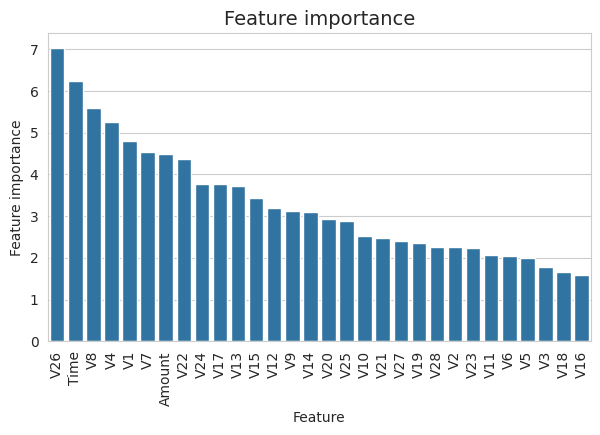

In [40]:
tmp=pd.DataFrame({'Feature':predictors,'Feature importance': clf.feature_importances_})
tmp= tmp.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize=(7,4))
plt.title('Feature importance',fontsize=14)
s=sns.barplot(x='Feature',y='Feature importance',data=tmp)
s.tick_params(axis='x',rotation=90)
plt.show()

We can see that feature V26,Time has highest importance

<h3>Confusion matrix</h3>

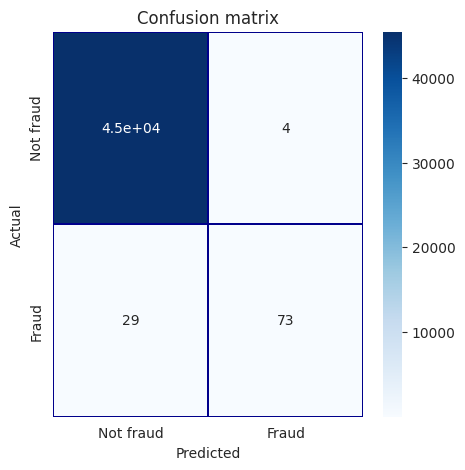

In [41]:
cm=pd.crosstab(valid_df[target].values,preds,rownames=['Actual'],colnames=['Predicted'])
fig, (ax1)=plt.subplots(ncols=1,figsize=(5,5))
sns.heatmap(cm,
           xticklabels=['Not fraud','Fraud'],
           yticklabels=['Not fraud','Fraud'],
           annot=True,ax=ax1,
            linewidths=.2,linecolor="darkblue",cmap="Blues")
plt.title('Confusion matrix',fontsize=12)
plt.show()

<h3>Calcualte ROC-AUC value</h3>

<h3>Area under curve</h3>

In [42]:
roc_auc_score(valid_df[target].values,preds)

np.float64(0.8577991493075996)

The ROC-AUC score of CatBoostClassifier is 0.86

<h2>XGBoost</h2>

XGBoost is gradiant boosting algorithm

<h3>Prepare the model</h3>

In [43]:
dtrain = xgb.DMatrix(train_df[predictors], train_df[target].values)
dvalid = xgb.DMatrix(valid_df[predictors], valid_df[target].values)
dtest = xgb.DMatrix(test_df[predictors], test_df[target].values)
watchlist=[(dtrain,'train'),(dvalid,'valid')]

params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

<h3>Train the model</h3>

In [44]:
model = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:771: FutureWarning:

Pass `evals` as keyword args.

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning:

[17:57:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "silent" } are not used.




[0]	train-auc:0.93758	valid-auc:0.88823
[50]	train-auc:0.98434	valid-auc:0.97558
[100]	train-auc:0.98999	valid-auc:0.97847
[150]	train-auc:0.99261	valid-auc:0.97674
[160]	train-auc:0.99304	valid-auc:0.97720


<h3>Plot variable importance</h3>

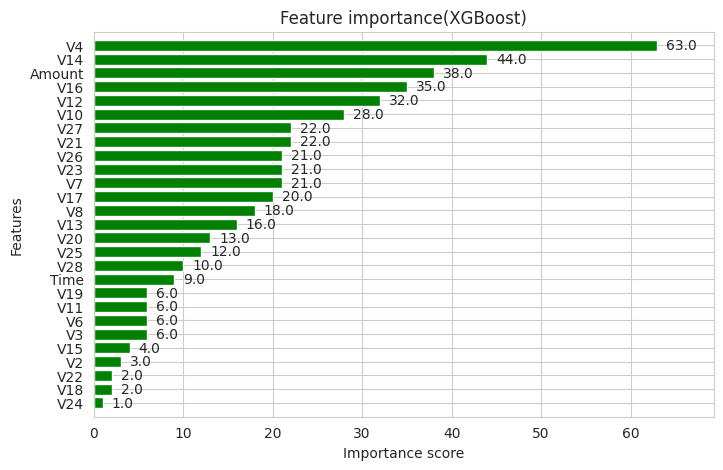

In [45]:
fig, (ax)=plt.subplots(ncols=1,figsize=(8,5))
xgb.plot_importance(model, height=0.8,title="Feature importance(XGBoost)",ax=ax,color="green")
plt.show()

We can see that "V4" is the most important feature after "v14" and "Amount"

<h3>Predicting test set</h3>

We will use the trained model now to predict the target value for the test set.

In [46]:
preds=model.predict(dtest)

<h3>Area under curve</h3>

Calculating ROC-AUC values

In [47]:
roc_auc_score(test_df[target].values,preds)

np.float64(0.9771017551264465)

The ROC-AUC score for prediction is 0.977

<h2>LightGBM</h2>

<h3>Define model parameters</h3>

In [48]:
params={
    'boosting_type':'gbdt',
    'objective':'binary',
    'metric':'auc',
    'learning_rate':0.05,
    'num_leaves':7,
    'max_depth':4,
    'min_child_samples':100,
    'max_bin':100,
    'subsample':0.9,
    'subsample_freq':1,
    'colsample_bytree':0.7,
    'min_child_weight':0,
    'min_split_gain':0,
    'nthread':8,
    'verbose':0,
    'scale_pos_weight':150,
    
}

<h3>Prepare the model</h3>

In [52]:
dtrain=lgb.Dataset(train_df[predictors].values,
                  label=train_df[target].values,
                  feature_name=predictors)

dvalid=lgb.Dataset(valid_df[predictors].values,
                  label=valid_df[target].values,
                  feature_name=predictors)

<h3>Running the model</h3>

In [63]:
evals_results = {}

callbacks = [
    lgb.early_stopping(stopping_rounds=2 * EARLY_STOP),
    lgb.log_evaluation(period=VERBOSE_EVAL),
    lgb.record_evaluation(evals_results) # This replaces evals_results argument
]

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    num_boost_round=MAX_ROUNDS,
    feval=None,
    callbacks=callbacks  # All "missing" arguments go here
)

Training until validation scores don't improve for 100 rounds
[50]	train's auc: 0.997909	valid's auc: 0.952288
[100]	train's auc: 0.999032	valid's auc: 0.945553
Early stopping, best iteration is:
[29]	train's auc: 0.996594	valid's auc: 0.957864


Best estimated score was for round 85, for which ROC-AUC values = 0.974

<h3>Plot for variable importance</h3>

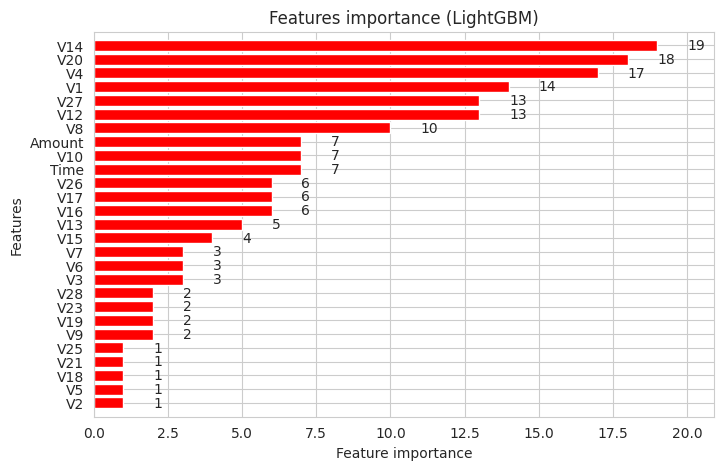

In [64]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
lgb.plot_importance(model, height=0.8, title="Features importance (LightGBM)", ax=ax,color="red") 
plt.show()

<h3>Predict test data</h3>

In [65]:
preds=model.predict(test_df[predictors])

<h3>Area under curve</h3>

Let's calculate the ROC-AUC values

In [66]:
roc_auc_score(test_df[target].values, preds)

np.float64(0.9473337202349548)